In [1]:
%pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
panel = pd.read_parquet('../data/processed/panel.parquet')

In [7]:
panel.head()

,date,region,median_price,state,mean_price,total_value,rate
0,2002-03-01,Adelaide,166.0,South Australia,NaN,NaN,NaN
1,2002-03-01,Brisbane,185.0,Queensland,NaN,NaN,NaN
2,2002-03-01,Canberra,245.0,Australian Capital Territory,NaN,NaN,NaN
3,2002-03-01,Darwin,190.0,Northern Territory,NaN,NaN,NaN
4,2002-03-01,Hobart,123.3,Tasmania,NaN,NaN,NaN


In [5]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1455 non-null   datetime64[us]
 1   region        1455 non-null   str           
 2   median_price  1413 non-null   float64       
 3   state         1455 non-null   str           
 4   mean_price    885 non-null    float64       
 5   total_value   885 non-null    float64       
 6   rate          915 non-null    float64       
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 112.2 KB


In [9]:
panel["region"].unique()

<ArrowStringArray>
[    'Adelaide',     'Brisbane',     'Canberra',       'Darwin',
       'Hobart',    'Melbourne',        'Perth',  'Rest of NSW',
   'Rest of NT', 'Rest of Qld.',   'Rest of SA', 'Rest of Tas.',
 'Rest of Vic.',   'Rest of WA',       'Sydney']
Length: 15, dtype: str

In [10]:
panel["date"].min()

Timestamp('2002-03-01 00:00:00')

In [11]:
panel["date"].max()

Timestamp('2026-03-01 00:00:00')

In [16]:
cols = ["median_price", "total_value", "mean_price", "rate"]

missing_per_region = panel[cols].isna().groupby(panel["region"]).sum()

missing_per_region

,median_price,total_value,mean_price,rate
region,,,,
Adelaide,0,38,38,36
Brisbane,0,38,38,36
Canberra,0,38,38,36
Darwin,0,38,38,36
Hobart,0,38,38,36
Melbourne,0,38,38,36
Perth,0,38,38,36
Rest of NSW,6,38,38,36
Rest of NT,6,38,38,36


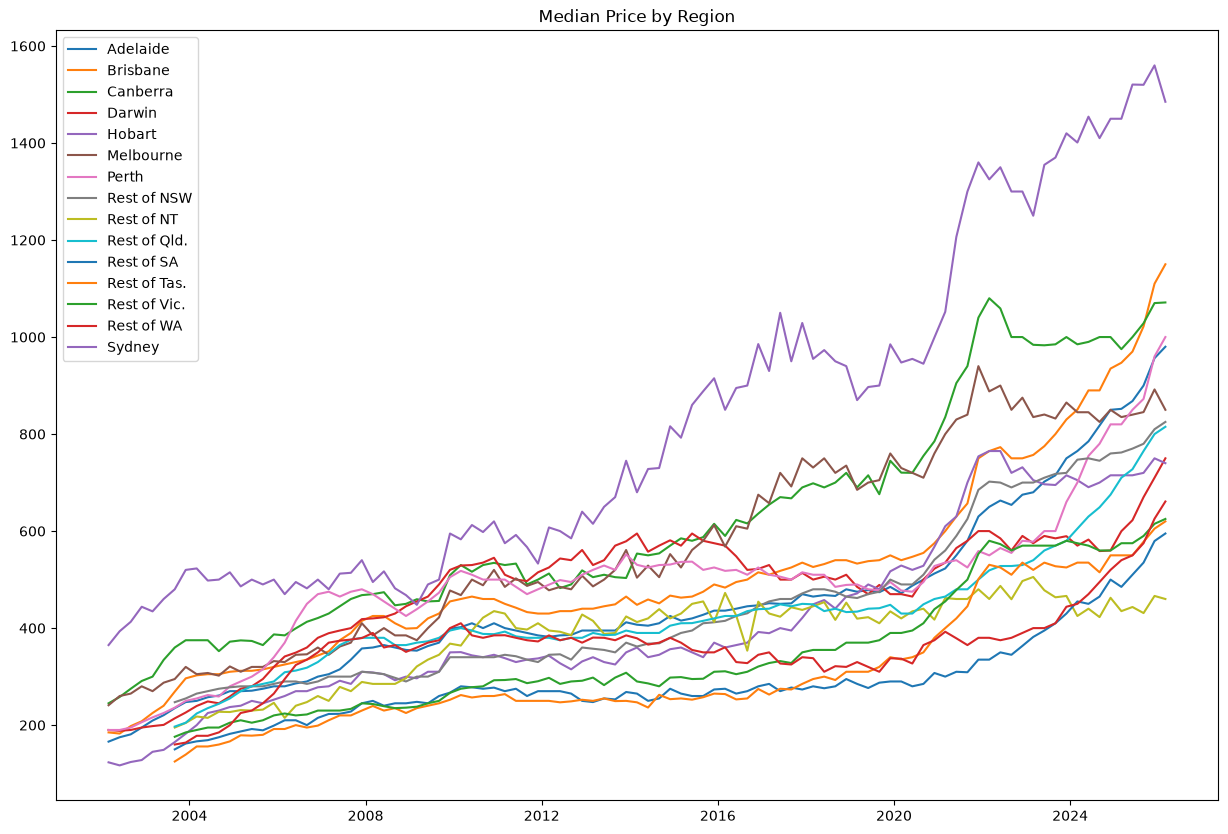

In [30]:
plt.figure(figsize=(15, 10))

for region, g in panel.groupby("region"):
    plt.plot(g["date"], g["median_price"], label=region)


plt.legend()
plt.title("Median Price by Region")
plt.savefig("../reports/figures/median_price_by_region.png", dpi=300)
plt.show()